<a href="https://colab.research.google.com/github/castrokelly/PPGIa/blob/main/atividade_cifar10_comparacao_modelos_G4_cache_drive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificação da base CIFAR-10
## Versão G4 com cache persistente no Google Drive

Comparação entre CNN do zero, extração de características, fine-tuning,
data augmentation e Vision Transformer.

## 2. Instalação das dependências

Instalação somente das bibliotecas que precisam ser controladas neste experimento.

- `pandas==2.2.2`: preservação da versão esperada pelo ambiente do Google Colab e pelas bibliotecas RAPIDS instaladas.
- `transformers==4.57.6`: compatibilidade com a estrutura `vit.vit.encoder.layer` e com os pesos do checkpoint ViT.
- `huggingface-hub==0.36.2`: versão compatível com o Transformers 4.57.6.
- `accelerate`, `reportlab`, `tqdm` e `pillow`: utilitários usados no treinamento e no relatório.

A opção `--upgrade` foi removida. Ela atualizava indiscriminadamente pacotes já fornecidos pelo Colab, incluindo o Pandas, e criava conflitos com o ambiente base.

In [1]:
!nvidia-smi --query-gpu=name,memory.total,driver_version --format=csv

name, memory.total [MiB], driver_version
NVIDIA RTX PRO 6000 Blackwell Server Edition, 97887 MiB, 580.82.07


## 1. Cache persistente no Google Drive

Montagem do Google Drive antes da instalação e antes da importação do TensorFlow.

Persistência dos seguintes arquivos:

- base CIFAR-10 baixada pelo Keras;
- pesos ImageNet da MobileNetV2 e da ResNet50;
- checkpoint e configuração do ViT no Hugging Face Hub;
- cache do PyTorch;
- checkpoints, tabelas, imagens e relatório da atividade.

Na primeira execução, o download ainda será necessário. Nas execuções seguintes,
os arquivos serão recuperados diretamente do Drive, mesmo após troca ou encerramento
do ambiente do Colab.

A opção `MIGRAR_CACHE_LOCAL_EXISTENTE=True` copia para o Drive uma base ou modelo
que já tenha sido baixado na sessão atual. Essa célula deve ser executada antes de
reiniciar a sessão que ainda contém o download.

In [1]:
import os
import shutil
from pathlib import Path

USAR_CACHE_NO_DRIVE = True
MIGRAR_CACHE_LOCAL_EXISTENTE = False

CACHE_LOCAL_KERAS_ANTERIOR = Path.home() / ".keras"
CACHE_LOCAL_HF_ANTERIOR = Path.home() / ".cache" / "huggingface"
CACHE_LOCAL_TORCH_ANTERIOR = Path.home() / ".cache" / "torch"

if USAR_CACHE_NO_DRIVE:
    try:
        from google.colab import drive

        drive.mount(
            "/content/drive",
            force_remount=False,
        )

        PASTA_PERSISTENTE = (
            Path("/content/drive/MyDrive")
            / "atividade_cifar10_cache"
        )
    except ImportError:
        PASTA_PERSISTENTE = (
            Path.cwd()
            / "atividade_cifar10_cache"
        )
else:
    PASTA_PERSISTENTE = (
        Path.cwd()
        / "atividade_cifar10_cache"
    )

PASTA_PERSISTENTE.mkdir(
    parents=True,
    exist_ok=True,
)

KERAS_HOME_PERSISTENTE = (
    PASTA_PERSISTENTE
    / "keras"
)
HF_HOME_PERSISTENTE = (
    PASTA_PERSISTENTE
    / "huggingface"
)
TORCH_HOME_PERSISTENTE = (
    PASTA_PERSISTENTE
    / "torch"
)
SAIDA_PERSISTENTE = (
    PASTA_PERSISTENTE
    / "resultados_cifar10"
)

for pasta in [
    KERAS_HOME_PERSISTENTE,
    HF_HOME_PERSISTENTE,
    TORCH_HOME_PERSISTENTE,
    SAIDA_PERSISTENTE,
]:
    pasta.mkdir(
        parents=True,
        exist_ok=True,
    )

def copiar_cache_existente(
    origem,
    destino,
    descricao,
):
    origem = Path(origem)
    destino = Path(destino)

    if not origem.exists():
        print(
            f"{descricao}: nenhum cache local "
            "encontrado para migração."
        )
        return

    print(
        f"{descricao}: copiando o cache local "
        f"de {origem} para {destino}..."
    )

    shutil.copytree(
        origem,
        destino,
        dirs_exist_ok=True,
    )

    print(
        f"{descricao}: migração concluída."
    )

if MIGRAR_CACHE_LOCAL_EXISTENTE:
    copiar_cache_existente(
        CACHE_LOCAL_KERAS_ANTERIOR,
        KERAS_HOME_PERSISTENTE,
        "Keras/CIFAR-10",
    )

    copiar_cache_existente(
        CACHE_LOCAL_HF_ANTERIOR,
        HF_HOME_PERSISTENTE,
        "Hugging Face",
    )

    copiar_cache_existente(
        CACHE_LOCAL_TORCH_ANTERIOR,
        TORCH_HOME_PERSISTENTE,
        "PyTorch",
    )

# Variáveis definidas antes de importar TensorFlow, Keras, Torch ou Transformers.
os.environ["KERAS_HOME"] = str(
    KERAS_HOME_PERSISTENTE
)
os.environ["HF_HOME"] = str(
    HF_HOME_PERSISTENTE
)
os.environ["HF_HUB_CACHE"] = str(
    HF_HOME_PERSISTENTE / "hub"
)
os.environ["TRANSFORMERS_CACHE"] = str(
    HF_HOME_PERSISTENTE / "transformers"
)
os.environ["TORCH_HOME"] = str(
    TORCH_HOME_PERSISTENTE
)
os.environ["XDG_CACHE_HOME"] = str(
    PASTA_PERSISTENTE / "xdg"
)

print("Cache persistente:", PASTA_PERSISTENTE)
print("KERAS_HOME:", os.environ["KERAS_HOME"])
print("HF_HOME:", os.environ["HF_HOME"])
print("TORCH_HOME:", os.environ["TORCH_HOME"])
print("Saídas:", SAIDA_PERSISTENTE)

Mounted at /content/drive
Cache persistente: /content/drive/MyDrive/atividade_cifar10_cache
KERAS_HOME: /content/drive/MyDrive/atividade_cifar10_cache/keras
HF_HOME: /content/drive/MyDrive/atividade_cifar10_cache/huggingface
TORCH_HOME: /content/drive/MyDrive/atividade_cifar10_cache/torch
Saídas: /content/drive/MyDrive/atividade_cifar10_cache/resultados_cifar10


In [2]:
%pip install -q \
    "pandas==2.2.2" \
    "transformers==4.57.6" \
    "huggingface-hub==0.36.2" \
    accelerate reportlab tqdm pillow

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


## 3. Importações, versões e inicialização da GPU

Inicialização do TensorFlow antes de qualquer importação ou chamada CUDA do PyTorch.

Essa ordem evita que duas bibliotecas carreguem contextos CUDA diferentes antes da
primeira operação do Keras. O TensorFlow recebe crescimento de memória, TF32 e um
teste mínimo de multiplicação de matrizes antes da criação da CNN.

A política padrão foi mantida em `float32`. A G4 continua utilizando aceleração TF32,
enquanto se evita o primeiro `Cast` em `float16` que expôs o contexto CUDA inválido.
Mixed precision pode ser reativada posteriormente, após a execução integral estável,
alterando `USAR_MIXED_PRECISION_TF=True`.

In [3]:
import os

# Configuração aplicada antes da importação do TensorFlow.
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "1"

import gc
import sys
import time
import json
import random
import warnings
import subprocess
from pathlib import Path
from importlib.metadata import version as package_version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

# TensorFlow é configurado antes de qualquer importação ou chamada CUDA do PyTorch.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision

SEMENTE = 42
USAR_MIXED_PRECISION_TF = False

os.environ["PYTHONHASHSEED"] = str(SEMENTE)
random.seed(SEMENTE)
np.random.seed(SEMENTE)

gpus_tf = tf.config.list_physical_devices("GPU")

for gpu in gpus_tf:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as erro:
        raise RuntimeError(
            "O TensorFlow inicializou a GPU antes da configuração de memória. "
            "Reinicie a sessão do Colab e execute o notebook desde o início."
        ) from erro

tf.random.set_seed(SEMENTE)

# TF32 acelera operações float32 em GPUs modernas sem exigir mixed_float16.
try:
    tf.config.experimental.enable_tensor_float_32_execution(True)
except Exception:
    pass

if USAR_MIXED_PRECISION_TF and gpus_tf:
    mixed_precision.set_global_policy("mixed_float16")
else:
    mixed_precision.set_global_policy("float32")

VERSAO_TRANSFORMERS_ESPERADA = "4.57.6"
VERSAO_PANDAS_ESPERADA = "2.2.2"
VERSAO_HUB_ESPERADA = "0.36.2"

VERSAO_TRANSFORMERS = package_version("transformers")
VERSAO_HUB = package_version("huggingface-hub")
VERSAO_TORCH = package_version("torch")

if VERSAO_TRANSFORMERS != VERSAO_TRANSFORMERS_ESPERADA:
    raise RuntimeError(
        "A sessão ainda está usando transformers "
        f"{VERSAO_TRANSFORMERS}, mas o notebook exige "
        f"{VERSAO_TRANSFORMERS_ESPERADA}. Reinicie o ambiente do Colab "
        "e execute novamente desde a primeira célula."
    )

if pd.__version__ != VERSAO_PANDAS_ESPERADA:
    raise RuntimeError(
        "A sessão ainda está usando pandas "
        f"{pd.__version__}, mas o notebook exige "
        f"{VERSAO_PANDAS_ESPERADA}. Reinicie o ambiente do Colab "
        "e execute novamente desde a primeira célula."
    )

if VERSAO_HUB != VERSAO_HUB_ESPERADA:
    raise RuntimeError(
        "A sessão ainda está usando huggingface-hub "
        f"{VERSAO_HUB}, mas o notebook exige "
        f"{VERSAO_HUB_ESPERADA}. Reinicie o ambiente do Colab "
        "e execute novamente desde a primeira célula."
    )

def consultar_gpu_nvidia():
    if not gpus_tf:
        return "CPU", 0.0

    try:
        saida_nvidia = subprocess.check_output(
            [
                "nvidia-smi",
                "--query-gpu=name,memory.total",
                "--format=csv,noheader,nounits",
            ],
            text=True,
        ).strip().splitlines()[0]

        nome, memoria_mib = [
            parte.strip()
            for parte in saida_nvidia.rsplit(",", 1)
        ]

        return nome, float(memoria_mib) / 1024
    except Exception:
        detalhes = tf.config.experimental.get_device_details(gpus_tf[0])
        return detalhes.get("device_name", "GPU NVIDIA"), 0.0

NOME_GPU, VRAM_GB = consultar_gpu_nvidia()

# Teste mínimo do contexto CUDA do TensorFlow antes da criação dos modelos.
if gpus_tf:
    try:
        with tf.device("/GPU:0"):
            a = tf.ones((64, 64), dtype=tf.float32)
            b = tf.ones((64, 64), dtype=tf.float32)
            teste_gpu_tf = tf.reduce_sum(tf.matmul(a, b))
        valor_teste_gpu_tf = float(teste_gpu_tf.numpy())
    except Exception as erro:
        raise RuntimeError(
            "O contexto CUDA do TensorFlow está inválido antes do primeiro modelo. "
            "Não execute novamente apenas esta célula. Reinicie a sessão do Colab, "
            "selecione a GPU e execute desde a célula de instalação. "
            "O PyTorch não deve ser importado antes desta verificação."
        ) from erro
else:
    valor_teste_gpu_tf = None

print("Python:", sys.version.split()[0])
print("TensorFlow:", tf.__version__)
print("PyTorch instalado:", VERSAO_TORCH)
print("Pandas:", pd.__version__)
print("Transformers:", VERSAO_TRANSFORMERS)
print("Hugging Face Hub:", VERSAO_HUB)
print("Política Keras:", mixed_precision.global_policy())
print("Dispositivo:", NOME_GPU)
print(f"VRAM disponível: {VRAM_GB:.1f} GB")
print("Teste TensorFlow GPU:", valor_teste_gpu_tf)

Python: 3.12.13
TensorFlow: 2.20.0
PyTorch instalado: 2.11.0+cu128
Pandas: 2.2.2
Transformers: 4.57.6
Hugging Face Hub: 0.36.2
Política Keras: <DTypePolicy "float32">
Dispositivo: NVIDIA A100-SXM4-80GB
VRAM disponível: 80.0 GB
Teste TensorFlow GPU: 262144.0


## 4. Configuração do experimento

Configuração dos modos rápido e completo.

Os tamanhos de lote são ajustados conforme a memória disponível. Na G4 com cerca de
96 GB, o ViT utiliza lote 128 e a extração de características utiliza lote 256.
O lote das CNNs treinadas permanece mais conservador para evitar mudança excessiva
na dinâmica de otimização.

In [4]:
MODO_RAPIDO = False
EXECUTAR_VIT = True
EXECUTAR_ABLACOES = True

TAMANHO_TRANSFERENCIA = 96

# Lotes conservadores para treinamento Keras e maiores para inferência.
BATCH_CNN = 128 if not MODO_RAPIDO else 64
BATCH_TRANSFERENCIA = 128 if (VRAM_GB >= 40 and not MODO_RAPIDO) else 32
BATCH_EXTRACAO = 256 if VRAM_GB >= 40 else BATCH_TRANSFERENCIA
BATCH_VIT = (
    128 if VRAM_GB >= 80 and not MODO_RAPIDO
    else 64 if VRAM_GB >= 40 and not MODO_RAPIDO
    else 16 if MODO_RAPIDO
    else 32
)

NUM_WORKERS_VIT = min(8, max(2, (os.cpu_count() or 4) // 2))

if MODO_RAPIDO:
    AMOSTRAS_TREINO_POR_CLASSE = 700
    AMOSTRAS_VALIDACAO_POR_CLASSE = 150
    AMOSTRAS_TESTE_POR_CLASSE = 250

    EPOCAS_CNN_ZERO = 5
    EPOCAS_CABECA = 2
    EPOCAS_FINE_TUNING = 2
    EPOCAS_ABLACAO = 2
    EPOCAS_VIT = 1
else:
    AMOSTRAS_TREINO_POR_CLASSE = None
    AMOSTRAS_VALIDACAO_POR_CLASSE = None
    AMOSTRAS_TESTE_POR_CLASSE = None

    EPOCAS_CNN_ZERO = 25
    EPOCAS_CABECA = 5
    EPOCAS_FINE_TUNING = 7
    EPOCAS_ABLACAO = 4
    EPOCAS_VIT = 3

PASTA_SAIDA = (
    SAIDA_PERSISTENTE
    if "SAIDA_PERSISTENTE" in globals()
    else Path("resultados_cifar10")
)
PASTA_SAIDA.mkdir(
    parents=True,
    exist_ok=True,
)

CLASSES = [
    "avião", "automóvel", "pássaro", "gato", "cervo",
    "cachorro", "sapo", "cavalo", "navio", "caminhão",
]

print("Modo rápido:", MODO_RAPIDO)
print("Pasta de saída:", PASTA_SAIDA.resolve())
print("Batch CNN:", BATCH_CNN)
print("Batch transferência:", BATCH_TRANSFERENCIA)
print("Batch extração:", BATCH_EXTRACAO)
print("Batch ViT:", BATCH_VIT)
print("Workers ViT:", NUM_WORKERS_VIT)

Modo rápido: False
Pasta de saída: /content/drive/MyDrive/atividade_cifar10_cache/resultados_cifar10
Batch CNN: 128
Batch transferência: 128
Batch extração: 256
Batch ViT: 128
Workers ViT: 6


## 4. Carregamento da CIFAR-10

Carregamento da divisão oficial da CIFAR-10 pelo Keras. A base contém 50.000 imagens de treinamento e 10.000 imagens de teste, todas coloridas e com dimensão 32 × 32.

In [5]:
caminho_cache_cifar = (
    Path(os.environ.get(
        "KERAS_HOME",
        str(Path.home() / ".keras"),
    ))
    / "datasets"
)

print(
    "Diretório persistente da CIFAR-10:",
    caminho_cache_cifar,
)
print(
    "Arquivos existentes antes do carregamento:",
    [
        item.name
        for item in caminho_cache_cifar.glob("*cifar*")
    ]
    if caminho_cache_cifar.exists()
    else [],
)

inicio_carga_cifar = time.perf_counter()

(x_train_full, y_train_full), (x_test_full, y_test_full) = (
    keras.datasets.cifar10.load_data()
)

tempo_carga_cifar = (
    time.perf_counter()
    - inicio_carga_cifar
)

y_train_full = y_train_full.ravel().astype("int64")
y_test_full = y_test_full.ravel().astype("int64")

print(
    f"Tempo de carregamento da CIFAR-10: "
    f"{tempo_carga_cifar:.1f} segundos"
)
print("Treinamento:", x_train_full.shape, y_train_full.shape)
print("Teste:", x_test_full.shape, y_test_full.shape)
print("Classes:", np.unique(y_train_full))
print(
    "Arquivos persistidos:",
    [
        item.name
        for item in caminho_cache_cifar.glob("*cifar*")
    ],
)

Diretório persistente da CIFAR-10: /content/drive/MyDrive/atividade_cifar10_cache/keras/datasets
Arquivos existentes antes do carregamento: ['cifar-10-batches-py-target_archive', 'cifar-10-batches-py-target']
Tempo de carregamento da CIFAR-10: 26.1 segundos
Treinamento: (50000, 32, 32, 3) (50000,)
Teste: (10000, 32, 32, 3) (10000,)
Classes: [0 1 2 3 4 5 6 7 8 9]
Arquivos persistidos: ['cifar-10-batches-py-target_archive', 'cifar-10-batches-py-target']


### Verificação da persistência da CIFAR-10

Confirmação de que o cache foi gravado no diretório persistente. O carregamento das
próximas sessões deve utilizar esses arquivos, sem novo download.

In [6]:
arquivos_cifar_persistidos = list(
    caminho_cache_cifar.glob("*cifar*")
)

if not arquivos_cifar_persistidos:
    raise RuntimeError(
        "A CIFAR-10 foi carregada, mas nenhum arquivo foi encontrado "
        f"no cache persistente {caminho_cache_cifar}. "
        "Confirme que a célula de cache foi executada antes da importação do Keras."
    )

for arquivo in arquivos_cifar_persistidos:
    tamanho_mb = (
        arquivo.stat().st_size / 1024**2
        if arquivo.is_file()
        else sum(
            item.stat().st_size
            for item in arquivo.rglob("*")
            if item.is_file()
        ) / 1024**2
    )

    print(
        f"{arquivo.name}: "
        f"{tamanho_mb:.1f} MB"
    )

print(
    "Cache da CIFAR-10 confirmado no Google Drive."
)

cifar-10-batches-py-target_archive: 162.6 MB
cifar-10-batches-py-target: 177.6 MB
Cache da CIFAR-10 confirmado no Google Drive.


## 5. Separação entre treinamento, validação e teste

Preservação da base oficial de teste: retiro 10% da base de treinamento para validação. A seleção do melhor modelo será feita pela validação, não pelo teste.

In [7]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.10,
    random_state=SEMENTE,
    stratify=y_train_full,
)

x_test = x_test_full
y_test = y_test_full

def amostrar_por_classe(x, y, quantidade_por_classe, semente):
    if quantidade_por_classe is None:
        return x, y

    rng = np.random.default_rng(semente)
    indices = []

    for classe in np.unique(y):
        candidatos = np.flatnonzero(y == classe)
        n = min(quantidade_por_classe, len(candidatos))
        indices.extend(rng.choice(candidatos, size=n, replace=False))

    indices = np.asarray(indices)
    rng.shuffle(indices)
    return x[indices], y[indices]

x_train, y_train = amostrar_por_classe(
    x_train, y_train, AMOSTRAS_TREINO_POR_CLASSE, SEMENTE
)
x_val, y_val = amostrar_por_classe(
    x_val, y_val, AMOSTRAS_VALIDACAO_POR_CLASSE, SEMENTE + 1
)
x_test, y_test = amostrar_por_classe(
    x_test, y_test, AMOSTRAS_TESTE_POR_CLASSE, SEMENTE + 2
)

print("Treino usado:", x_train.shape, y_train.shape)
print("Validação usada:", x_val.shape, y_val.shape)
print("Teste usado:", x_test.shape, y_test.shape)

Treino usado: (45000, 32, 32, 3) (45000,)
Validação usada: (5000, 32, 32, 3) (5000,)
Teste usado: (10000, 32, 32, 3) (10000,)


## 6. Inspeção visual da base

Visualização de uma imagem de cada classe para confirmar os rótulos e a qualidade das entradas.

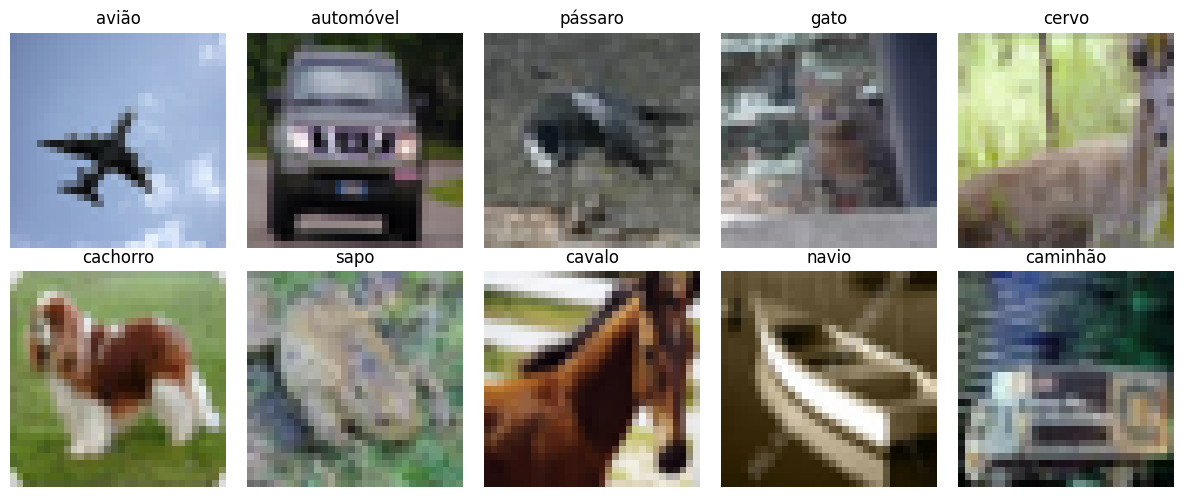

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for classe, ax in enumerate(axes.ravel()):
    indice = np.flatnonzero(y_train == classe)[0]
    ax.imshow(x_train[indice])
    ax.set_title(CLASSES[classe])
    ax.axis("off")

plt.tight_layout()
plt.show()

## 7. Funções comuns de avaliação

Centralização do cálculo das métricas e armazenamento das predições. A precisão, o recall e o F1 são calculados com média macro, dando o mesmo peso às dez classes.

Implementação de bootstrap pareado. Ele estima um intervalo de confiança de 95% para a diferença de acurácia entre dois modelos avaliados nas mesmas imagens. Consideramos a diferença estatisticamente compatível com zero quando o intervalo contém zero.

In [9]:
resultados = []
predicoes_teste = {}
predicoes_validacao = {}
detalhes_modelos = {}

def calcular_metricas(y_real, y_pred):
    return {
        "acuracia": accuracy_score(y_real, y_pred),
        "precisao_macro": precision_score(
            y_real, y_pred, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_real, y_pred, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(
            y_real, y_pred, average="macro", zero_division=0
        ),
    }

def registrar_resultado(
    nome,
    etapa,
    y_pred_val,
    y_pred_test,
    tempo_segundos,
    observacoes="",
):
    metricas_val = calcular_metricas(y_val, y_pred_val)
    metricas_test = calcular_metricas(y_test, y_pred_test)

    linha = {
        "modelo": nome,
        "etapa": etapa,
        "acuracia_validacao": metricas_val["acuracia"],
        "acuracia_teste": metricas_test["acuracia"],
        "precisao_macro_teste": metricas_test["precisao_macro"],
        "recall_macro_teste": metricas_test["recall_macro"],
        "f1_macro_teste": metricas_test["f1_macro"],
        "tempo_segundos": tempo_segundos,
        "observacoes": observacoes,
    }

    # Substituição do resultado anterior quando uma célula é executada novamente.
    resultados[:] = [
        item for item in resultados
        if item["modelo"] != nome
    ]
    resultados.append(linha)

    predicoes_validacao[nome] = np.asarray(y_pred_val)
    predicoes_teste[nome] = np.asarray(y_pred_test)
    return linha

def bootstrap_diferenca_acuracia(
    y_real,
    pred_a,
    pred_b,
    n_bootstrap=4000,
    semente=42,
):
    rng = np.random.default_rng(semente)
    y_real = np.asarray(y_real)
    pred_a = np.asarray(pred_a)
    pred_b = np.asarray(pred_b)

    diferencas = np.empty(n_bootstrap, dtype=float)
    n = len(y_real)

    for i in range(n_bootstrap):
        indices = rng.integers(0, n, size=n)
        acc_a = accuracy_score(y_real[indices], pred_a[indices])
        acc_b = accuracy_score(y_real[indices], pred_b[indices])
        diferencas[i] = acc_a - acc_b

    li, ls = np.quantile(diferencas, [0.025, 0.975])

    return {
        "diferenca_observada": (
            accuracy_score(y_real, pred_a)
            - accuracy_score(y_real, pred_b)
        ),
        "limite_inferior": li,
        "limite_superior": ls,
        "significativa": bool(li > 0 or ls < 0),
    }

def nome_arquivo_seguro(nome):
    return "".join(
        caractere if caractere.isalnum() or caractere in "-_"
        else "_"
        for caractere in nome
    )

def caminho_checkpoint(nome):
    return PASTA_SAIDA / f"{nome_arquivo_seguro(nome)}.weights.h5"

def criar_callbacks(nome):
    caminho = caminho_checkpoint(nome)

    return [
        keras.callbacks.ModelCheckpoint(
            filepath=str(caminho),
            monitor="val_accuracy",
            mode="max",
            save_best_only=True,
            save_weights_only=True,
            verbose=0,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            mode="max",
            patience=4 if not MODO_RAPIDO else 2,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=0.4,
            patience=2,
            min_lr=1e-6,
            verbose=1,
        ),
    ]

def carregar_melhores_pesos(modelo, nome):
    caminho = caminho_checkpoint(nome)
    if not caminho.exists():
        raise FileNotFoundError(
            f"Checkpoint não encontrado: {caminho}"
        )
    modelo.load_weights(caminho)

def predizer_keras(modelo, x, batch_size):
    probabilidades = modelo.predict(
        x,
        batch_size=batch_size,
        verbose=0,
    )
    return probabilidades.argmax(axis=1)

# Etapa 1 - CNN criada do zero

Nesta etapa, construímos uma CNN sem pesos pré-treinados. Usarei três blocos convolucionais, normalização em lote, pooling e dropout. A camada `GlobalAveragePooling2D` reduz a quantidade de parâmetros em comparação com uma camada `Flatten` extensa.

In [10]:
def criar_cnn_do_zero():
    keras.utils.set_random_seed(SEMENTE)

    entradas = keras.Input(shape=(32, 32, 3))
    x = layers.Rescaling(1.0 / 255)(entradas)

    for filtros, dropout in [(32, 0.15), (64, 0.20), (128, 0.30)]:
        x = layers.Conv2D(
            filtros, 3, padding="same", use_bias=False
        )(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)

        x = layers.Conv2D(
            filtros, 3, padding="same", use_bias=False
        )(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)

        x = layers.MaxPooling2D()(x)
        x = layers.Dropout(dropout)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.40)(x)

    logits = layers.Dense(10)(x)
    saidas = layers.Activation(
        "softmax",
        dtype="float32",
        name="predictions",
    )(logits)

    modelo = keras.Model(
        entradas,
        saidas,
        name="cnn_do_zero",
    )

    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )
    return modelo

cnn_zero = criar_cnn_do_zero()
cnn_zero.summary()

Model: "cnn_do_zero"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,456 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 323,946 (1.24 MB)

 Trainable params: 323,050 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)

## 8. Treinamento e avaliação da CNN do zero

Treinamento da rede com os dados originais, sem aumento de dados, para estabelecer uma linha de base. Depois, calculamos as métricas de validação e teste.

In [11]:
inicio = time.perf_counter()

historico_cnn_zero = cnn_zero.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCAS_CNN_ZERO,
    batch_size=BATCH_CNN,
    callbacks=criar_callbacks("cnn_zero"),
    verbose=2,
)

carregar_melhores_pesos(cnn_zero, "cnn_zero")

tempo = time.perf_counter() - inicio

pred_val = predizer_keras(cnn_zero, x_val, BATCH_CNN)
pred_test = predizer_keras(cnn_zero, x_test, BATCH_CNN)

registrar_resultado(
    nome="CNN do zero",
    etapa="1 - CNN criada do zero",
    y_pred_val=pred_val,
    y_pred_test=pred_test,
    tempo_segundos=tempo,
    observacoes=(
        "CNN treinada sem pesos da ImageNet e sem data augmentation; "
        "melhores pesos selecionados pela acurácia de validação."
    ),
)

Epoch 1/25
352/352 - 31s - 87ms/step - accuracy: 0.4754 - loss: 1.4319 - val_accuracy: 0.2362 - val_loss: 2.4067 - learning_rate: 0.0010
Epoch 2/25
352/352 - 2s - 5ms/step - accuracy: 0.6289 - loss: 1.0421 - val_accuracy: 0.6170 - val_loss: 1.0794 - learning_rate: 0.0010
Epoch 3/25
352/352 - 2s - 5ms/step - accuracy: 0.6800 - loss: 0.9065 - val_accuracy: 0.6518 - val_loss: 0.9741 - learning_rate: 0.0010
Epoch 4/25
352/352 - 2s - 5ms/step - accuracy: 0.7107 - loss: 0.8193 - val_accuracy: 0.6322 - val_loss: 1.1602 - learning_rate: 0.0010
Epoch 5/25

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0004000000189989805.
352/352 - 2s - 5ms/step - accuracy: 0.7443 - loss: 0.7328 - val_accuracy: 0.6556 - val_loss: 1.0833 - learning_rate: 0.0010
Epoch 6/25
352/352 - 2s - 5ms/step - accuracy: 0.7834 - loss: 0.6186 - val_accuracy: 0.7872 - val_loss: 0.6109 - learning_rate: 4.0000e-04
Epoch 7/25
352/352 - 2s - 4ms/step - accuracy: 0.7991 - loss: 0.5855 - val_accuracy: 0.7832 - val_loss: 0.6

{'modelo': 'CNN do zero',
 'etapa': '1 - CNN criada do zero',
 'acuracia_validacao': 0.8468,
 'acuracia_teste': 0.8455,
 'precisao_macro_teste': 0.845704942164889,
 'recall_macro_teste': 0.8455,
 'f1_macro_teste': 0.8443686290657982,
 'tempo_segundos': 71.399614412,
 'observacoes': 'CNN treinada sem pesos da ImageNet e sem data augmentation; melhores pesos selecionados pela acurácia de validação.'}

# Etapa 2 - Rede pré-treinada como extratora de características

Comparação das duas redes pré-treinadas na ImageNet:

- MobileNetV2, uma arquitetura mais leve;
- ResNet50, uma arquitetura mais profunda e mais pesada.

Congelamento das redes, extração de um vetor de características de cada imagem e treinamento de dois classificadores rasos:

- regressão logística;
- SVM linear.

Essa comparação responde à questão sobre o impacto de substituir uma CNN mais pesada por uma MobileNet.

In [12]:
from tensorflow.keras.applications import (
    MobileNetV2,
    ResNet50,
)
from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input as preprocess_mobilenet,
)
from tensorflow.keras.applications.resnet50 import (
    preprocess_input as preprocess_resnet,
)

def criar_extrator(nome_backbone):
    keras.utils.set_random_seed(SEMENTE)

    if nome_backbone == "MobileNetV2":
        backbone = MobileNetV2(
            include_top=False,
            weights="imagenet",
            pooling="avg",
            input_shape=(
                TAMANHO_TRANSFERENCIA,
                TAMANHO_TRANSFERENCIA,
                3,
            ),
        )
        preprocessamento = preprocess_mobilenet
    elif nome_backbone == "ResNet50":
        backbone = ResNet50(
            include_top=False,
            weights="imagenet",
            pooling="avg",
            input_shape=(
                TAMANHO_TRANSFERENCIA,
                TAMANHO_TRANSFERENCIA,
                3,
            ),
        )
        preprocessamento = preprocess_resnet
    else:
        raise ValueError(
            f"Backbone desconhecido: {nome_backbone}"
        )

    backbone.trainable = False

    entradas = keras.Input(shape=(32, 32, 3))
    x = layers.Resizing(
        TAMANHO_TRANSFERENCIA,
        TAMANHO_TRANSFERENCIA,
    )(entradas)
    x = preprocessamento(x)
    saidas = backbone(x, training=False)

    return keras.Model(
        entradas,
        saidas,
        name=f"extrator_{nome_backbone}",
    )

def extrair_features(modelo, imagens):
    features = modelo.predict(
        imagens,
        batch_size=BATCH_EXTRACAO,
        verbose=1,
    )
    # O Scikit-learn opera de forma mais estável com float32.
    return features.astype(np.float32, copy=False)

classificadores_rasos = {
    "Regressão logística": Pipeline([
        ("padronizacao", StandardScaler()),
        ("modelo", LogisticRegression(
            max_iter=5000,
            C=1.0,
            n_jobs=-1,
            random_state=SEMENTE,
        )),
    ]),
    "SVM linear": Pipeline([
        ("padronizacao", StandardScaler()),
        ("modelo", LinearSVC(
            C=1.0,
            dual="auto",
            max_iter=25_000,
            random_state=SEMENTE,
        )),
    ]),
}

## 9. Extração e classificação das características profundas

Executando a extração de uma rede por vez para controlar o uso de memória. Para cada backbone, são treinados os dois classificadores rasos e registradas as predições.

In [13]:
melhor_modelo_raso_por_backbone = {}

for nome_backbone in ["MobileNetV2", "ResNet50"]:
    print("\nBackbone:", nome_backbone)
    inicio_backbone = time.perf_counter()

    extrator = criar_extrator(nome_backbone)

    feat_train = extrair_features(extrator, x_train)
    feat_val = extrair_features(extrator, x_val)
    feat_test = extrair_features(extrator, x_test)

    tempo_extracao = time.perf_counter() - inicio_backbone
    candidatos = []

    for nome_clf, clf in classificadores_rasos.items():
        inicio_clf = time.perf_counter()
        clf.fit(feat_train, y_train)

        pred_val = clf.predict(feat_val)
        pred_test = clf.predict(feat_test)

        tempo_classificador = time.perf_counter() - inicio_clf
        tempo_total = tempo_extracao + tempo_classificador

        nome_resultado = f"{nome_backbone} + {nome_clf}"

        linha = registrar_resultado(
            nome=nome_resultado,
            etapa="2 - Extração de características",
            y_pred_val=pred_val,
            y_pred_test=pred_test,
            tempo_segundos=tempo_total,
            observacoes=(
                f"{nome_backbone} congelada, pooling médio global "
                f"e classificador {nome_clf}."
            ),
        )

        detalhes_modelos[nome_resultado] = {
            "backbone": nome_backbone,
            "classificador": nome_clf,
        }
        candidatos.append(linha)

    melhor = max(
        candidatos,
        key=lambda item: item["acuracia_validacao"],
    )
    melhor_modelo_raso_por_backbone[nome_backbone] = melhor["modelo"]

    del extrator, feat_train, feat_val, feat_test
    keras.backend.clear_session()
    gc.collect()

print(melhor_modelo_raso_por_backbone)


Backbone: MobileNetV2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
176/176 ━━━━━━━━━━━━━━━━━━━━ 36s 103ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 765ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 296ms/step

Backbone: ResNet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
176/176 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 160ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step
{'MobileNetV2': 'MobileNetV2 + SVM linear', 'ResNet50': 'ResNet50 + SVM linear'}


## 10. Teste da questão sobre a MobileNet

Comparamos o melhor classificador raso obtido com MobileNetV2 com o melhor classificador obtido com ResNet50. Depois,  calculamos a diferença de acurácia e um intervalo bootstrap de 95%.

In [14]:
nome_mobile = melhor_modelo_raso_por_backbone["MobileNetV2"]
nome_resnet = melhor_modelo_raso_por_backbone["ResNet50"]

teste_mobilenet = bootstrap_diferenca_acuracia(
    y_test,
    predicoes_teste[nome_mobile],
    predicoes_teste[nome_resnet],
    n_bootstrap=4000,
    semente=SEMENTE,
)

print("MobileNet:", nome_mobile)
print("ResNet:", nome_resnet)
print(json.dumps(teste_mobilenet, indent=2, ensure_ascii=False))

MobileNet: MobileNetV2 + SVM linear
ResNet: ResNet50 + SVM linear
{
  "diferenca_observada": 0.02180000000000004,
  "limite_inferior": 0.013497499999999961,
  "limite_superior": 0.030399999999999983,
  "significativa": true
}


# Etapa 3 - Fine-tuning de uma CNN pré-treinada

Usamos a `MobileNetV2` como base para o fine-tuning. Primeiro, congelando toda a base e treinando apenas a cabeça de classificação. Depois, liberamos as últimas camadas convolucionais e continuamos o treinamento com taxa de aprendizado menor.

Mantemos as camadas de Batch Normalization congeladas durante o ajuste fino, pois isso tende a estabilizar a adaptação em bases menores.

In [15]:
def criar_modelo_fine_tuning_mobilenet(
    pooling="average",
    augmentation=None,
):
    keras.utils.set_random_seed(SEMENTE)

    entradas = keras.Input(shape=(32, 32, 3))
    x = entradas

    if augmentation is not None:
        x = augmentation(x)

    x = layers.Resizing(
        TAMANHO_TRANSFERENCIA,
        TAMANHO_TRANSFERENCIA,
    )(x)
    x = preprocess_mobilenet(x)

    backbone = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=(
            TAMANHO_TRANSFERENCIA,
            TAMANHO_TRANSFERENCIA,
            3,
        ),
    )
    backbone.trainable = False

    # training=False mantém as Batch Normalization em modo de inferência.
    x = backbone(x, training=False)

    if pooling == "average":
        x = layers.GlobalAveragePooling2D()(x)
    elif pooling == "max":
        x = layers.GlobalMaxPooling2D()(x)
    elif pooling == "flatten":
        x = layers.Flatten()(x)
    else:
        raise ValueError(
            f"Pooling desconhecido: {pooling}"
        )

    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.35)(x)

    logits = layers.Dense(10)(x)
    saidas = layers.Activation(
        "softmax",
        dtype="float32",
        name="predictions",
    )(logits)

    modelo = keras.Model(
        entradas,
        saidas,
    )
    return modelo, backbone

def liberar_ultimas_camadas(backbone, quantidade=30):
    backbone.trainable = True

    for camada in backbone.layers[:-quantidade]:
        camada.trainable = False

    for camada in backbone.layers[-quantidade:]:
        if isinstance(camada, layers.BatchNormalization):
            camada.trainable = False
        else:
            camada.trainable = True

def compilar_modelo(modelo, otimizador):
    modelo.compile(
        optimizer=otimizador,
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )

## 11. Treinamento em duas fases

Agora, treinamos a cabeça com a base congelada. Em seguida, liberamos as últimas 30 camadas e continuamos com uma taxa de aprendizado de `1e-5`.

In [16]:
keras.backend.clear_session()
gc.collect()

modelo_ft, backbone_ft = criar_modelo_fine_tuning_mobilenet(
    pooling="average",
    augmentation=None,
)

compilar_modelo(
    modelo_ft,
    keras.optimizers.Adam(learning_rate=1e-3),
)

inicio = time.perf_counter()

modelo_ft.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCAS_CABECA,
    batch_size=BATCH_TRANSFERENCIA,
    callbacks=criar_callbacks("ft_mobilenet_cabeca"),
    verbose=2,
)

carregar_melhores_pesos(
    modelo_ft,
    "ft_mobilenet_cabeca",
)

liberar_ultimas_camadas(
    backbone_ft,
    quantidade=30,
)

compilar_modelo(
    modelo_ft,
    keras.optimizers.Adam(learning_rate=1e-5),
)

historico_ft = modelo_ft.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCAS_FINE_TUNING,
    batch_size=BATCH_TRANSFERENCIA,
    callbacks=criar_callbacks("ft_mobilenet_final"),
    verbose=2,
)

carregar_melhores_pesos(
    modelo_ft,
    "ft_mobilenet_final",
)

tempo = time.perf_counter() - inicio

pred_val = predizer_keras(
    modelo_ft,
    x_val,
    BATCH_TRANSFERENCIA,
)
pred_test = predizer_keras(
    modelo_ft,
    x_test,
    BATCH_TRANSFERENCIA,
)

registrar_resultado(
    nome="MobileNetV2 fine-tuning",
    etapa="3 - Fine-tuning de CNN",
    y_pred_val=pred_val,
    y_pred_test=pred_test,
    tempo_segundos=tempo,
    observacoes=(
        "Cabeça treinada com a base congelada; últimas 30 camadas "
        "liberadas; melhores pesos de cada fase restaurados."
    ),
)

Epoch 1/5
352/352 - 57s - 162ms/step - accuracy: 0.8009 - loss: 0.5923 - val_accuracy: 0.8528 - val_loss: 0.4176 - learning_rate: 0.0010
Epoch 2/5
352/352 - 3s - 9ms/step - accuracy: 0.8564 - loss: 0.4145 - val_accuracy: 0.8656 - val_loss: 0.3847 - learning_rate: 0.0010
Epoch 3/5
352/352 - 3s - 8ms/step - accuracy: 0.8749 - loss: 0.3580 - val_accuracy: 0.8716 - val_loss: 0.3702 - learning_rate: 0.0010
Epoch 4/5
352/352 - 3s - 9ms/step - accuracy: 0.8888 - loss: 0.3193 - val_accuracy: 0.8756 - val_loss: 0.3722 - learning_rate: 0.0010
Epoch 5/5
352/352 - 3s - 7ms/step - accuracy: 0.9001 - loss: 0.2853 - val_accuracy: 0.8714 - val_loss: 0.3671 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 4.
Epoch 1/7
352/352 - 34s - 96ms/step - accuracy: 0.9063 - loss: 0.2642 - val_accuracy: 0.8874 - val_loss: 0.3407 - learning_rate: 1.0000e-05
Epoch 2/7
352/352 - 4s - 11ms/step - accuracy: 0.9227 - loss: 0.2211 - val_accuracy: 0.8902 - val_loss: 0.3356 - learning_rate: 

{'modelo': 'MobileNetV2 fine-tuning',
 'etapa': '3 - Fine-tuning de CNN',
 'acuracia_validacao': 0.8968,
 'acuracia_teste': 0.8911,
 'precisao_macro_teste': 0.8915307004352859,
 'recall_macro_teste': 0.8911,
 'f1_macro_teste': 0.8909600554490573,
 'tempo_segundos': 125.87991339700011,
 'observacoes': 'Cabeça treinada com a base congelada; últimas 30 camadas liberadas; melhores pesos de cada fase restaurados.'}

# Etapa 4 - Data augmentation e estudos de ablação

Nesta etapa, avaliamos as três questões propostas:

1. `Flatten` versus `GlobalMaxPooling2D`;
2. Adam versus SGD e RMSprop;
3. diferentes intensidades de data augmentation.

Para tornar a comparação viável, mantemos a `MobileNetV2` congelada durante as ablações e alteramos apenas o fator que está sendo analisado. Depois, partimos para o fine-tuning da melhor configuração escolhida pela validação.

## 12. Definição das estratégias de aumento e dos otimizadores

Quatro políticas:

- nenhuma;
- básica;
- moderada;
- forte.

Para evitar transformações verticais porque elas podem criar imagens incompatíveis com as classes naturais da CIFAR-10.

In [17]:
def criar_augmentation(nome):
    if nome == "nenhuma":
        return None

    if nome == "basica":
        return keras.Sequential(
            [
                layers.RandomFlip("horizontal"),
                layers.RandomTranslation(0.08, 0.08),
            ],
            name="augmentation_basica",
        )

    if nome == "moderada":
        return keras.Sequential(
            [
                layers.RandomFlip("horizontal"),
                layers.RandomTranslation(0.10, 0.10),
                layers.RandomRotation(0.07),
                layers.RandomZoom(0.12),
                layers.RandomContrast(0.12),
            ],
            name="augmentation_moderada",
        )

    if nome == "forte":
        return keras.Sequential(
            [
                layers.RandomFlip("horizontal"),
                layers.RandomTranslation(0.14, 0.14),
                layers.RandomRotation(0.12),
                layers.RandomZoom(0.20),
                layers.RandomContrast(0.20),
            ],
            name="augmentation_forte",
        )

    raise ValueError(
        f"Estratégia desconhecida: {nome}"
    )

def criar_otimizador(nome, lr=None):
    if nome == "Adam":
        return keras.optimizers.Adam(
            learning_rate=1e-3 if lr is None else lr
        )

    if nome == "SGD":
        return keras.optimizers.SGD(
            learning_rate=1e-2 if lr is None else lr,
            momentum=0.9,
            nesterov=True,
        )

    if nome == "RMSprop":
        return keras.optimizers.RMSprop(
            learning_rate=1e-3 if lr is None else lr,
            momentum=0.2,
        )

    raise ValueError(
        f"Otimizador desconhecido: {nome}"
    )

cache_ablacoes = {}

def executar_ablacao(pooling, otimizador, augmentation):
    chave = (pooling, otimizador, augmentation)

    if chave in cache_ablacoes:
        return cache_ablacoes[chave]

    keras.backend.clear_session()
    gc.collect()
    keras.utils.set_random_seed(SEMENTE)

    modelo, backbone = criar_modelo_fine_tuning_mobilenet(
        pooling=pooling,
        augmentation=criar_augmentation(augmentation),
    )
    backbone.trainable = False

    compilar_modelo(
        modelo,
        criar_otimizador(otimizador),
    )

    nome = (
        f"Ablação | pooling={pooling} | "
        f"opt={otimizador} | aug={augmentation}"
    )
    nome_checkpoint = nome_arquivo_seguro(nome)

    inicio = time.perf_counter()

    modelo.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=EPOCAS_ABLACAO,
        batch_size=BATCH_TRANSFERENCIA,
        callbacks=criar_callbacks(nome_checkpoint),
        verbose=2,
    )

    carregar_melhores_pesos(
        modelo,
        nome_checkpoint,
    )

    tempo = time.perf_counter() - inicio

    pred_val = predizer_keras(
        modelo,
        x_val,
        BATCH_TRANSFERENCIA,
    )
    pred_test = predizer_keras(
        modelo,
        x_test,
        BATCH_TRANSFERENCIA,
    )

    linha = registrar_resultado(
        nome=nome,
        etapa="4 - Estudo de ablação",
        y_pred_val=pred_val,
        y_pred_test=pred_test,
        tempo_segundos=tempo,
        observacoes=(
            f"Backbone congelada; pooling={pooling}; "
            f"otimizador={otimizador}; augmentation={augmentation}."
        ),
    )

    cache_ablacoes[chave] = linha

    del modelo, backbone
    keras.backend.clear_session()
    gc.collect()

    return linha

## 13. Ablação do pooling

Manter Adam e aumento básico fixos. Então, comparar `Flatten` com `GlobalMaxPooling2D`.

In [18]:
if EXECUTAR_ABLACOES:
    resultado_flatten = executar_ablacao(
        pooling="flatten",
        otimizador="Adam",
        augmentation="basica",
    )

    resultado_globalmax = executar_ablacao(
        pooling="max",
        otimizador="Adam",
        augmentation="basica",
    )

    teste_pooling = bootstrap_diferenca_acuracia(
        y_test,
        predicoes_teste[resultado_globalmax["modelo"]],
        predicoes_teste[resultado_flatten["modelo"]],
        semente=SEMENTE + 10,
    )

    print(json.dumps(
        teste_pooling,
        indent=2,
        ensure_ascii=False,
    ))

Epoch 1/4
352/352 - 14s - 39ms/step - accuracy: 0.7068 - loss: 0.9576 - val_accuracy: 0.8430 - val_loss: 0.4498 - learning_rate: 0.0010
Epoch 2/4
352/352 - 5s - 14ms/step - accuracy: 0.7737 - loss: 0.6710 - val_accuracy: 0.8570 - val_loss: 0.4130 - learning_rate: 0.0010
Epoch 3/4
352/352 - 5s - 14ms/step - accuracy: 0.7941 - loss: 0.6085 - val_accuracy: 0.8636 - val_loss: 0.4045 - learning_rate: 0.0010
Epoch 4/4
352/352 - 5s - 15ms/step - accuracy: 0.8034 - loss: 0.5756 - val_accuracy: 0.8650 - val_loss: 0.3926 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 4.
Epoch 1/4
352/352 - 11s - 32ms/step - accuracy: 0.7022 - loss: 0.9049 - val_accuracy: 0.8348 - val_loss: 0.4783 - learning_rate: 0.0010
Epoch 2/4
352/352 - 5s - 15ms/step - accuracy: 0.7691 - loss: 0.6734 - val_accuracy: 0.8460 - val_loss: 0.4399 - learning_rate: 0.0010
Epoch 3/4
352/352 - 5s - 14ms/step - accuracy: 0.7859 - loss: 0.6232 - val_accuracy: 0.8510 - val_loss: 0.4251 - learning_rate: 0

## 14. Ablação do otimizador

Aqui, usamos `GlobalMaxPooling2D` e aumento básico. Comparaamos Adam, SGD com momentum e RMSprop. Escolhemos a melhor opção pela acurácia de validação.

In [19]:
if EXECUTAR_ABLACOES:
    resultados_otimizadores = []

    for nome_otimizador in ["Adam", "SGD", "RMSprop"]:
        resultados_otimizadores.append(
            executar_ablacao(
                pooling="max",
                otimizador=nome_otimizador,
                augmentation="basica",
            )
        )

    melhor_otimizador_linha = max(
        resultados_otimizadores,
        key=lambda item: item["acuracia_validacao"],
    )
    melhor_otimizador = (
        melhor_otimizador_linha["modelo"]
        .split("opt=")[1]
        .split("|")[0]
        .strip()
    )

    print("Melhor otimizador pela validação:", melhor_otimizador)

    if melhor_otimizador != "Adam":
        nome_adam = next(
            item["modelo"]
            for item in resultados_otimizadores
            if "opt=Adam" in item["modelo"]
        )

        teste_otimizador = bootstrap_diferenca_acuracia(
            y_test,
            predicoes_teste[melhor_otimizador_linha["modelo"]],
            predicoes_teste[nome_adam],
            semente=SEMENTE + 11,
        )
    else:
        teste_otimizador = {
            "diferenca_observada": 0.0,
            "limite_inferior": 0.0,
            "limite_superior": 0.0,
            "significativa": False,
        }

    print(json.dumps(
        teste_otimizador,
        indent=2,
        ensure_ascii=False,
    ))
else:
    melhor_otimizador = "Adam"

Epoch 1/4
352/352 - 11s - 31ms/step - accuracy: 0.6963 - loss: 0.9044 - val_accuracy: 0.8350 - val_loss: 0.4840 - learning_rate: 0.0100
Epoch 2/4
352/352 - 5s - 14ms/step - accuracy: 0.7606 - loss: 0.6956 - val_accuracy: 0.8356 - val_loss: 0.4691 - learning_rate: 0.0100
Epoch 3/4
352/352 - 5s - 14ms/step - accuracy: 0.7766 - loss: 0.6501 - val_accuracy: 0.8526 - val_loss: 0.4343 - learning_rate: 0.0100
Epoch 4/4
352/352 - 5s - 14ms/step - accuracy: 0.7826 - loss: 0.6247 - val_accuracy: 0.8560 - val_loss: 0.4174 - learning_rate: 0.0100
Restoring model weights from the end of the best epoch: 4.
Epoch 1/4
352/352 - 11s - 31ms/step - accuracy: 0.6888 - loss: 1.0128 - val_accuracy: 0.8038 - val_loss: 0.6038 - learning_rate: 0.0010
Epoch 2/4
352/352 - 5s - 14ms/step - accuracy: 0.7584 - loss: 0.7088 - val_accuracy: 0.8378 - val_loss: 0.4741 - learning_rate: 0.0010
Epoch 3/4
352/352 - 5s - 14ms/step - accuracy: 0.7802 - loss: 0.6550 - val_accuracy: 0.8454 - val_loss: 0.4615 - learning_rate: 0

## 15. Ablação das políticas de data augmentation

Mantemos `GlobalMaxPooling2D` e o melhor otimizador da etapa anterior. Comparação de ausência de aumento, aumento básico, moderado e forte.

In [20]:
if EXECUTAR_ABLACOES:
    resultados_augmentation = []

    for nome_aug in ["nenhuma", "basica", "moderada", "forte"]:
        resultados_augmentation.append(
            executar_ablacao(
                pooling="max",
                otimizador=melhor_otimizador,
                augmentation=nome_aug,
            )
        )

    melhor_augmentation_linha = max(
        resultados_augmentation,
        key=lambda item: item["acuracia_validacao"],
    )

    melhor_augmentation = (
        melhor_augmentation_linha["modelo"]
        .split("aug=")[1]
        .strip()
    )

    nome_sem_aug = next(
        item["modelo"]
        for item in resultados_augmentation
        if "aug=nenhuma" in item["modelo"]
    )

    teste_augmentation = bootstrap_diferenca_acuracia(
        y_test,
        predicoes_teste[melhor_augmentation_linha["modelo"]],
        predicoes_teste[nome_sem_aug],
        semente=SEMENTE + 12,
    )

    print("Melhor augmentation pela validação:", melhor_augmentation)
    print(json.dumps(
        teste_augmentation,
        indent=2,
        ensure_ascii=False,
    ))
else:
    melhor_augmentation = "moderada"

Epoch 1/4
352/352 - 26s - 74ms/step - accuracy: 0.7705 - loss: 0.7159 - val_accuracy: 0.8456 - val_loss: 0.4296 - learning_rate: 0.0010
Epoch 2/4
352/352 - 3s - 9ms/step - accuracy: 0.8384 - loss: 0.4765 - val_accuracy: 0.8560 - val_loss: 0.4160 - learning_rate: 0.0010
Epoch 3/4
352/352 - 3s - 9ms/step - accuracy: 0.8555 - loss: 0.4183 - val_accuracy: 0.8714 - val_loss: 0.3842 - learning_rate: 0.0010
Epoch 4/4
352/352 - 2s - 7ms/step - accuracy: 0.8683 - loss: 0.3802 - val_accuracy: 0.8668 - val_loss: 0.3884 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 3.
Epoch 1/4
352/352 - 13s - 36ms/step - accuracy: 0.5580 - loss: 1.3094 - val_accuracy: 0.7624 - val_loss: 0.6947 - learning_rate: 0.0010
Epoch 2/4
352/352 - 5s - 13ms/step - accuracy: 0.6280 - loss: 1.0585 - val_accuracy: 0.7598 - val_loss: 0.6898 - learning_rate: 0.0010
Epoch 3/4
352/352 - 5s - 15ms/step - accuracy: 0.6522 - loss: 1.0002 - val_accuracy: 0.7856 - val_loss: 0.6168 - learning_rate: 0.00

## 16. Fine-tuning da melhor configuração da etapa 4

Reconstruímos a melhor combinação escolhida pela validação. Primeiro, treinamos a cabeça com a MobileNetV2 congelada. Em seguida, liberamos as últimas 30 camadas e fazemos um ajuste fino com taxa de aprendizado menor.

In [21]:
keras.backend.clear_session()
gc.collect()
keras.utils.set_random_seed(SEMENTE)

modelo_aug, backbone_aug = criar_modelo_fine_tuning_mobilenet(
    pooling="max",
    augmentation=criar_augmentation(melhor_augmentation),
)

compilar_modelo(
    modelo_aug,
    criar_otimizador(melhor_otimizador),
)

inicio = time.perf_counter()

modelo_aug.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCAS_CABECA,
    batch_size=BATCH_TRANSFERENCIA,
    callbacks=criar_callbacks("augmentation_melhor_cabeca"),
    verbose=2,
)

carregar_melhores_pesos(
    modelo_aug,
    "augmentation_melhor_cabeca",
)

liberar_ultimas_camadas(
    backbone_aug,
    quantidade=30,
)

compilar_modelo(
    modelo_aug,
    criar_otimizador(
        melhor_otimizador,
        lr=1e-5 if melhor_otimizador != "SGD" else 1e-4,
    ),
)

modelo_aug.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCAS_FINE_TUNING,
    batch_size=BATCH_TRANSFERENCIA,
    callbacks=criar_callbacks("augmentation_melhor_final"),
    verbose=2,
)

carregar_melhores_pesos(
    modelo_aug,
    "augmentation_melhor_final",
)

tempo = time.perf_counter() - inicio

pred_val = predizer_keras(
    modelo_aug,
    x_val,
    BATCH_TRANSFERENCIA,
)
pred_test = predizer_keras(
    modelo_aug,
    x_test,
    BATCH_TRANSFERENCIA,
)

registrar_resultado(
    nome="MobileNetV2 fine-tuning + augmentation",
    etapa="4 - Fine-tuning com data augmentation",
    y_pred_val=pred_val,
    y_pred_test=pred_test,
    tempo_segundos=tempo,
    observacoes=(
        f"Pooling GlobalMax; otimizador={melhor_otimizador}; "
        f"augmentation={melhor_augmentation}; últimas 30 camadas liberadas; "
        "melhores pesos de cada fase restaurados."
    ),
)

Epoch 1/5
352/352 - 24s - 69ms/step - accuracy: 0.7705 - loss: 0.7159 - val_accuracy: 0.8456 - val_loss: 0.4296 - learning_rate: 0.0010
Epoch 2/5
352/352 - 3s - 9ms/step - accuracy: 0.8384 - loss: 0.4765 - val_accuracy: 0.8560 - val_loss: 0.4160 - learning_rate: 0.0010
Epoch 3/5
352/352 - 3s - 9ms/step - accuracy: 0.8555 - loss: 0.4183 - val_accuracy: 0.8714 - val_loss: 0.3842 - learning_rate: 0.0010
Epoch 4/5
352/352 - 2s - 7ms/step - accuracy: 0.8683 - loss: 0.3802 - val_accuracy: 0.8668 - val_loss: 0.3884 - learning_rate: 0.0010
Epoch 5/5

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0004000000189989805.
352/352 - 2s - 7ms/step - accuracy: 0.8765 - loss: 0.3522 - val_accuracy: 0.8670 - val_loss: 0.3903 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 3.
Epoch 1/7
352/352 - 29s - 81ms/step - accuracy: 0.8826 - loss: 0.3403 - val_accuracy: 0.8836 - val_loss: 0.3521 - learning_rate: 1.0000e-05
Epoch 2/7
352/352 - 4s - 11ms/step - accuracy: 0.898

{'modelo': 'MobileNetV2 fine-tuning + augmentation',
 'etapa': '4 - Fine-tuning com data augmentation',
 'acuracia_validacao': 0.8954,
 'acuracia_teste': 0.889,
 'precisao_macro_teste': 0.8892130212192171,
 'recall_macro_teste': 0.889,
 'f1_macro_teste': 0.8888485175920318,
 'tempo_segundos': 88.21178881300011,
 'observacoes': 'Pooling GlobalMax; otimizador=Adam; augmentation=nenhuma; últimas 30 camadas liberadas; melhores pesos de cada fase restaurados.'}

# Etapa 5 - Ajuste fino de um Vision Transformer

Nesta etapa, usamos um ViT pré-treinado. Congelamos a maior parte do modelo, liberamos o classificador e os últimos blocos do encoder e por fim, realizamos ajuste fino na CIFAR-10.

Como o ViT opera com patches, redimensionamos as imagens para 224 × 224. No modo rápido, liberamos apenas o último bloco; no modo completo, os dois últimos.

In [22]:
if EXECUTAR_VIT:
    keras.backend.clear_session()
    gc.collect()

    # Importação tardia: o PyTorch só recebe acesso à GPU depois que
    # todas as etapas TensorFlow/Keras foram concluídas.
    import torch

    torch.manual_seed(SEMENTE)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEMENTE)
        torch.set_float32_matmul_precision("high")

    from torch.utils.data import Dataset, DataLoader
    from torchvision import transforms
    from transformers import (
        AutoImageProcessor,
        ViTForImageClassification,
        get_cosine_schedule_with_warmup,
    )
    from tqdm.auto import tqdm

    DISPOSITIVO = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    if DISPOSITIVO.type != "cuda":
        warnings.warn(
            "O ViT será executado em CPU. A etapa será muito demorada."
        )

    MODELO_VIT = "google/vit-base-patch16-224-in21k"
    processador_vit = AutoImageProcessor.from_pretrained(
        MODELO_VIT
    )

    media_vit = processador_vit.image_mean
    desvio_vit = processador_vit.image_std

    transformacao_treino_vit = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize(
            (256, 256),
            antialias=True,
        ),
        transforms.RandomResizedCrop(
            224,
            scale=(0.80, 1.00),
            antialias=True,
        ),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(
            media_vit,
            desvio_vit,
        ),
    ])

    transformacao_avaliacao_vit = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize(
            (224, 224),
            antialias=True,
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            media_vit,
            desvio_vit,
        ),
    ])

    class CIFARArrayDataset(Dataset):
        def __init__(
            self,
            imagens,
            rotulos,
            transformacao,
        ):
            self.imagens = imagens
            self.rotulos = rotulos
            self.transformacao = transformacao

        def __len__(self):
            return len(self.rotulos)

        def __getitem__(self, indice):
            imagem = self.transformacao(
                self.imagens[indice]
            )
            rotulo = int(
                self.rotulos[indice]
            )
            return imagem, rotulo

    train_vit_ds = CIFARArrayDataset(
        x_train,
        y_train,
        transformacao_treino_vit,
    )
    val_vit_ds = CIFARArrayDataset(
        x_val,
        y_val,
        transformacao_avaliacao_vit,
    )
    test_vit_ds = CIFARArrayDataset(
        x_test,
        y_test,
        transformacao_avaliacao_vit,
    )

    loader_kwargs = {
        "batch_size": BATCH_VIT,
        "num_workers": NUM_WORKERS_VIT,
        "pin_memory": torch.cuda.is_available(),
        "persistent_workers": NUM_WORKERS_VIT > 0,
    }

    if NUM_WORKERS_VIT > 0:
        loader_kwargs["prefetch_factor"] = 4

    train_vit_loader = DataLoader(
        train_vit_ds,
        shuffle=True,
        **loader_kwargs,
    )
    val_vit_loader = DataLoader(
        val_vit_ds,
        shuffle=False,
        **loader_kwargs,
    )
    test_vit_loader = DataLoader(
        test_vit_ds,
        shuffle=False,
        **loader_kwargs,
    )

    vit, info_carregamento = (
        ViTForImageClassification.from_pretrained(
            MODELO_VIT,
            num_labels=10,
            ignore_mismatched_sizes=True,
            id2label={
                i: nome
                for i, nome in enumerate(CLASSES)
            },
            label2id={
                nome: i
                for i, nome in enumerate(CLASSES)
            },
            output_loading_info=True,
            use_safetensors=True,
        )
    )

    chaves_ausentes = info_carregamento.get(
        "missing_keys",
        [],
    )
    chaves_inesperadas = info_carregamento.get(
        "unexpected_keys",
        [],
    )
    chaves_incompativeis = info_carregamento.get(
        "mismatched_keys",
        [],
    )

    ausentes_problematicas = [
        chave
        for chave in chaves_ausentes
        if "classifier" not in chave
    ]
    inesperadas_problematicas = [
        chave
        for chave in chaves_inesperadas
        if "pooler" not in chave
    ]
    incompativeis_problematicas = [
        item
        for item in chaves_incompativeis
        if "classifier" not in str(item)
    ]

    if (
        ausentes_problematicas
        or inesperadas_problematicas
        or incompativeis_problematicas
    ):
        raise RuntimeError(
            "O encoder pré-treinado não foi carregado corretamente.\n"
            f"Ausentes: {ausentes_problematicas[:8]}\n"
            f"Inesperadas: {inesperadas_problematicas[:8]}\n"
            f"Incompatíveis: {incompativeis_problematicas[:8]}"
        )

    if not (
        hasattr(vit.vit, "encoder")
        and hasattr(vit.vit.encoder, "layer")
    ):
        raise RuntimeError(
            "Estrutura ViT incompatível com transformers 4.57.6. "
            "Reinicie a sessão e execute novamente desde a instalação."
        )

    print("Encoder pré-treinado carregado corretamente.")
    print("Chaves ausentes permitidas:", chaves_ausentes)
    print("Chaves inesperadas permitidas:", chaves_inesperadas)
    print("Chaves incompatíveis permitidas:", chaves_incompativeis)

    # Congelamento inicial.
    for parametro in vit.parameters():
        parametro.requires_grad = False

    # Cabeça de classificação.
    for parametro in vit.classifier.parameters():
        parametro.requires_grad = True

    # Últimos blocos e normalização final.
    n_blocos = 1 if MODO_RAPIDO else 2

    for bloco in vit.vit.encoder.layer[-n_blocos:]:
        for parametro in bloco.parameters():
            parametro.requires_grad = True

    for parametro in vit.vit.layernorm.parameters():
        parametro.requires_grad = True

    vit.to(DISPOSITIVO)

    parametros_treinaveis = [
        parametro
        for parametro in vit.parameters()
        if parametro.requires_grad
    ]

    total_parametros = sum(
        parametro.numel()
        for parametro in vit.parameters()
    )
    total_treinavel = sum(
        parametro.numel()
        for parametro in parametros_treinaveis
    )

    print(
        f"Parâmetros treináveis: {total_treinavel:,} "
        f"de {total_parametros:,} "
        f"({100 * total_treinavel / total_parametros:.2f}%)"
    )

    otimizador_vit = torch.optim.AdamW(
        parametros_treinaveis,
        lr=2e-5,
        weight_decay=0.01,
    )

    total_passos = (
        len(train_vit_loader)
        * EPOCAS_VIT
    )
    passos_warmup = int(
        0.10 * total_passos
    )

    scheduler_vit = get_cosine_schedule_with_warmup(
        otimizador_vit,
        num_warmup_steps=passos_warmup,
        num_training_steps=total_passos,
    )

    usar_cuda = DISPOSITIVO.type == "cuda"
    tipo_amp = (
        torch.bfloat16
        if usar_cuda and torch.cuda.is_bf16_supported()
        else torch.float16
    )
    usar_scaler = (
        usar_cuda
        and tipo_amp == torch.float16
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=usar_scaler,
    )

    print("AMP:", tipo_amp if usar_cuda else "desativado")

    def avaliar_vit(modelo, loader):
        modelo.eval()
        predicoes = []
        rotulos = []
        perdas = []

        with torch.inference_mode():
            for imagens, y_batch in loader:
                imagens = imagens.to(
                    DISPOSITIVO,
                    non_blocking=True,
                )
                y_batch = y_batch.to(
                    DISPOSITIVO,
                    non_blocking=True,
                )

                with torch.amp.autocast(
                    "cuda",
                    dtype=tipo_amp,
                    enabled=usar_cuda,
                ):
                    saida = modelo(
                        pixel_values=imagens,
                        labels=y_batch,
                    )

                perdas.append(
                    float(saida.loss.detach().cpu())
                )
                predicoes.extend(
                    saida.logits
                    .argmax(dim=1)
                    .cpu()
                    .numpy()
                )
                rotulos.extend(
                    y_batch.cpu().numpy()
                )

        return (
            float(np.mean(perdas)),
            np.asarray(rotulos),
            np.asarray(predicoes),
        )

    melhor_acc_val_vit = -np.inf
    caminho_vit = PASTA_SAIDA / "melhor_vit.pt"
    inicio = time.perf_counter()

    for epoca in range(
        1,
        EPOCAS_VIT + 1,
    ):
        vit.train()
        perdas_treino = []

        barra = tqdm(
            train_vit_loader,
            desc=f"ViT — época {epoca}/{EPOCAS_VIT}",
            leave=True,
        )

        for imagens, y_batch in barra:
            imagens = imagens.to(
                DISPOSITIVO,
                non_blocking=True,
            )
            y_batch = y_batch.to(
                DISPOSITIVO,
                non_blocking=True,
            )

            otimizador_vit.zero_grad(
                set_to_none=True
            )

            with torch.amp.autocast(
                "cuda",
                dtype=tipo_amp,
                enabled=usar_cuda,
            ):
                saida = vit(
                    pixel_values=imagens,
                    labels=y_batch,
                )
                perda = saida.loss

            if usar_scaler:
                scaler.scale(perda).backward()
                scaler.unscale_(otimizador_vit)
                torch.nn.utils.clip_grad_norm_(
                    parametros_treinaveis,
                    max_norm=1.0,
                )
                scaler.step(otimizador_vit)
                scaler.update()
            else:
                perda.backward()
                torch.nn.utils.clip_grad_norm_(
                    parametros_treinaveis,
                    max_norm=1.0,
                )
                otimizador_vit.step()

            scheduler_vit.step()

            perda_item = float(
                perda.detach().cpu()
            )
            perdas_treino.append(
                perda_item
            )

            barra.set_postfix(
                loss=f"{np.mean(perdas_treino[-50:]):.4f}",
                lr=f"{scheduler_vit.get_last_lr()[0]:.2e}",
            )

        perda_val, y_val_vit, pred_val_vit = (
            avaliar_vit(
                vit,
                val_vit_loader,
            )
        )
        acc_val_vit = accuracy_score(
            y_val_vit,
            pred_val_vit,
        )

        print(
            f"Época {epoca}/{EPOCAS_VIT} — "
            f"loss treino={np.mean(perdas_treino):.4f} — "
            f"loss val={perda_val:.4f} — "
            f"acc val={acc_val_vit:.4f}"
        )

        if acc_val_vit > melhor_acc_val_vit:
            melhor_acc_val_vit = acc_val_vit
            torch.save(
                vit.state_dict(),
                caminho_vit,
            )

    try:
        estado_vit = torch.load(
            caminho_vit,
            map_location=DISPOSITIVO,
            weights_only=True,
        )
    except TypeError:
        estado_vit = torch.load(
            caminho_vit,
            map_location=DISPOSITIVO,
        )

    vit.load_state_dict(
        estado_vit
    )

    _, y_val_vit, pred_val_vit = avaliar_vit(
        vit,
        val_vit_loader,
    )
    _, y_test_vit, pred_test_vit = avaliar_vit(
        vit,
        test_vit_loader,
    )

    tempo = time.perf_counter() - inicio

    assert np.array_equal(
        y_val_vit,
        y_val,
    )
    assert np.array_equal(
        y_test_vit,
        y_test,
    )

    registrar_resultado(
        nome="ViT fine-tuning",
        etapa="5 - Fine-tuning de ViT",
        y_pred_val=pred_val_vit,
        y_pred_test=pred_test_vit,
        tempo_segundos=tempo,
        observacoes=(
            f"Modelo={MODELO_VIT}; classificador, layernorm final e últimos "
            f"{n_blocos} bloco(s) liberados; AMP={tipo_amp}."
        ),
    )

    del vit, estado_vit
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()
else:
    print("Etapa do ViT desativada.")

/usr/local/lib/python3.12/dist-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

...

Época 1/3 — loss treino=1.5197 — loss val=0.6082 — acc val=0.9680


ViT — época 2/3:   0%|          | 0/352 [00:00<?, ?it/s]

Época 2/3 — loss treino=0.4084 — loss val=0.2973 — acc val=0.9724


ViT — época 3/3:   0%|          | 0/352 [00:00<?, ?it/s]

Época 3/3 — loss treino=0.2902 — loss val=0.2718 — acc val=0.9722


# Consolidação dos resultados

Organização dos resultados por acurácia de validação. Dessa forma, escolhemos o melhor modelo sem utilizar a base de teste como critério de seleção.

In [24]:
df_resultados = (
    pd.DataFrame(resultados)
    .drop_duplicates(
        subset=["modelo"],
        keep="last",
    )
    .sort_values(
        by=[
            "acuracia_validacao",
            "f1_macro_teste",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

colunas_exibicao = [
    "modelo",
    "etapa",
    "acuracia_validacao",
    "acuracia_teste",
    "precisao_macro_teste",
    "recall_macro_teste",
    "f1_macro_teste",
    "tempo_segundos",
]

display(
    df_resultados[colunas_exibicao]
    .style.format({
        "acuracia_validacao": "{:.4f}",
        "acuracia_teste": "{:.4f}",
        "precisao_macro_teste": "{:.4f}",
        "recall_macro_teste": "{:.4f}",
        "f1_macro_teste": "{:.4f}",
        "tempo_segundos": "{:.1f}",
    })
)

df_resultados.to_csv(
    PASTA_SAIDA / "resultados_modelos.csv",
    index=False,
)

metadados_execucao = {
    "python": sys.version,
    "tensorflow": tf.__version__,
    "pytorch": VERSAO_TORCH,
    "transformers": VERSAO_TRANSFORMERS,
    "gpu": NOME_GPU,
    "vram_gb": VRAM_GB,
    "modo_rapido": MODO_RAPIDO,
    "batch_cnn": BATCH_CNN,
    "batch_transferencia": BATCH_TRANSFERENCIA,
    "batch_extracao": BATCH_EXTRACAO,
    "batch_vit": BATCH_VIT,
}

with open(
    PASTA_SAIDA / "metadados_execucao.json",
    "w",
    encoding="utf-8",
) as arquivo:
    json.dump(
        metadados_execucao,
        arquivo,
        ensure_ascii=False,
        indent=2,
    )

,modelo,etapa,acuracia_validacao,acuracia_teste,precisao_macro_teste,recall_macro_teste,f1_macro_teste,tempo_segundos
0,ViT fine-tuning,5 - Fine-tuning de ViT,0.9724,0.9690,0.9690,0.9690,0.9690,107.6
1,MobileNetV2 fine-tuning,3 - Fine-tuning de CNN,0.8968,0.8911,0.8915,0.8911,0.8910,125.9
2,MobileNetV2 fine-tuning + augmentation,4 - Fine-tuning com data augmentation,0.8954,0.8890,0.8892,0.8890,0.8888,88.2
3,Ablação | pooling=max | opt=Adam | aug=nenhuma,4 - Estudo de ablação,0.8714,0.8605,0.8606,0.8605,0.8602,35.7
4,Ablação | pooling=flatten | opt=Adam | aug=basica,4 - Estudo de ablação,0.8650,0.8620,0.8632,0.8620,0.8612,30.3
5,Ablação | pooling=max | opt=Adam | aug=basica,4 - Estudo de ablação,0.8590,0.8533,0.8564,0.8533,0.8531,27.4
6,Ablação | pooling=max | opt=SGD | aug=basica,4 - Estudo de ablação,0.8560,0.8515,0.8517,0.8515,0.8505,26.3
7,MobileNetV2 + SVM linear,2 - Extração de características,0.8560,0.8453,0.8447,0.8453,0.8448,245.9
8,Ablação | pooling=max | opt=RMSprop | aug=basica,4 - Estudo de ablação,0.8486,0.8435,0.8499,0.8435,0.8430,26.6
9,CNN do zero,1 - CNN criada do zero,0.8468,0.8455,0.8457,0.8455,0.8444,71.4


## 17. Melhor modelo e matriz de confusão

Selecionamos o primeiro modelo da tabela, pois ele apresentou a maior acurácia de validação. Em seguida, calculamos a matriz de confusão usando apenas as predições da base oficial de teste ou da amostra estratificada de teste no modo rápido.

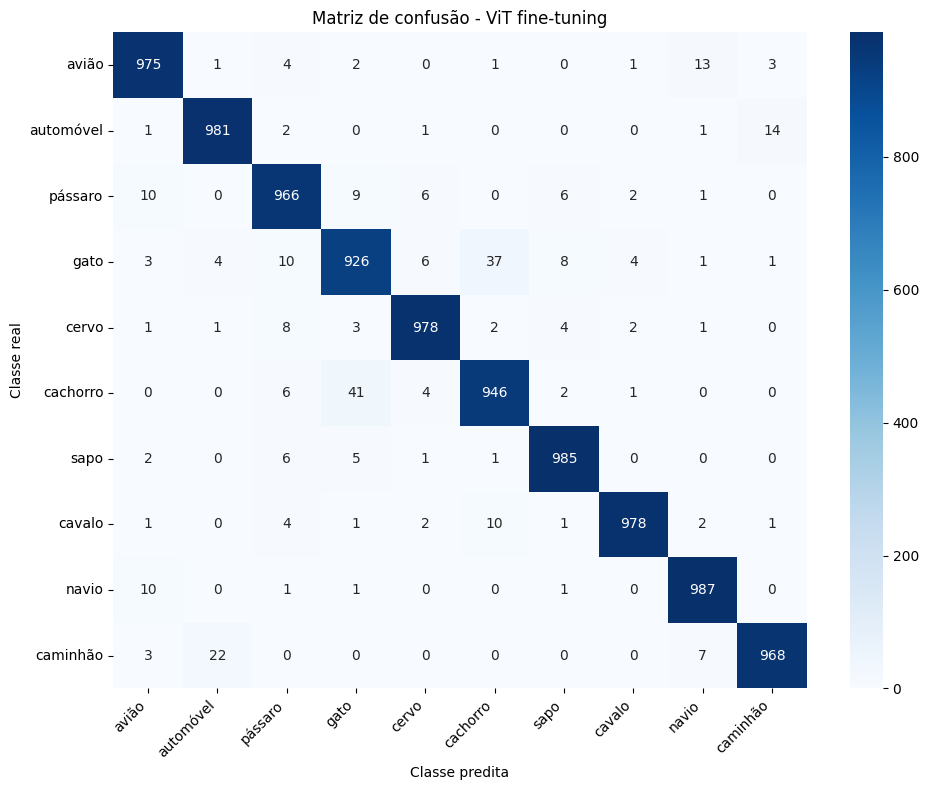

Melhor modelo: ViT fine-tuning
              precision    recall  f1-score   support

       avião       0.97      0.97      0.97      1000
   automóvel       0.97      0.98      0.98      1000
     pássaro       0.96      0.97      0.96      1000
        gato       0.94      0.93      0.93      1000
       cervo       0.98      0.98      0.98      1000
    cachorro       0.95      0.95      0.95      1000
        sapo       0.98      0.98      0.98      1000
      cavalo       0.99      0.98      0.98      1000
       navio       0.97      0.99      0.98      1000
    caminhão       0.98      0.97      0.97      1000

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [25]:
melhor_nome = df_resultados.iloc[0]["modelo"]
melhor_pred_test = predicoes_teste[melhor_nome]

matriz = confusion_matrix(
    y_test,
    melhor_pred_test,
    labels=np.arange(10),
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASSES,
    yticklabels=CLASSES,
)
plt.xlabel("Classe predita")
plt.ylabel("Classe real")
plt.title(f"Matriz de confusão - {melhor_nome}")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

caminho_matriz = PASTA_SAIDA / "matriz_confusao_melhor_modelo.png"
plt.savefig(caminho_matriz, dpi=180, bbox_inches="tight")
plt.show()

print("Melhor modelo:", melhor_nome)
print(classification_report(
    y_test,
    melhor_pred_test,
    target_names=CLASSES,
    zero_division=0,
))

## 18. Respostas automáticas às questões em aberto

Célula para unificar os testes e as métricas em respostas textuais. Só afirmo que houve impacto significativo quando o intervalo bootstrap de 95% não contém zero.

In [26]:
def interpretar_teste(teste, nome_a, nome_b):
    diff_pp = 100 * teste["diferenca_observada"]
    li_pp = 100 * teste["limite_inferior"]
    ls_pp = 100 * teste["limite_superior"]

    if teste["significativa"]:
        conclusao = (
            "O intervalo não contém zero, portanto a diferença foi "
            "estatisticamente relevante neste experimento."
        )
    else:
        conclusao = (
            "O intervalo contém zero, portanto eu não encontrei evidência "
            "de diferença significativa neste experimento."
        )

    return (
        f"{nome_a} - {nome_b}: diferença de {diff_pp:.2f} pontos "
        f"percentuais; IC95%=[{li_pp:.2f}, {ls_pp:.2f}]. "
        f"{conclusao}"
    )

respostas_questoes = {}

respostas_questoes["mobilenet"] = interpretar_teste(
    teste_mobilenet,
    nome_mobile,
    nome_resnet,
)

if EXECUTAR_ABLACOES:
    respostas_questoes["pooling"] = interpretar_teste(
        teste_pooling,
        "GlobalMaxPooling2D",
        "Flatten",
    )

    respostas_questoes["otimizador"] = (
        f"O melhor otimizador pela validação foi {melhor_otimizador}. "
        + interpretar_teste(
            teste_otimizador,
            melhor_otimizador,
            "Adam",
        )
    )

    respostas_questoes["augmentation"] = (
        f"A melhor política pela validação foi {melhor_augmentation}. "
        + interpretar_teste(
            teste_augmentation,
            melhor_augmentation,
            "sem aumento",
        )
    )

for pergunta, resposta in respostas_questoes.items():
    print("\\n", pergunta.upper())
    print(resposta)

with open(
    PASTA_SAIDA / "respostas_questoes.json",
    "w",
    encoding="utf-8",
) as arquivo:
    json.dump(
        respostas_questoes,
        arquivo,
        ensure_ascii=False,
        indent=2,
    )

\n MOBILENET
MobileNetV2 + SVM linear - ResNet50 + SVM linear: diferença de 2.18 pontos percentuais; IC95%=[1.35, 3.04]. O intervalo não contém zero, portanto a diferença foi estatisticamente relevante neste experimento.
\n POOLING
GlobalMaxPooling2D - Flatten: diferença de -0.87 pontos percentuais; IC95%=[-1.40, -0.32]. O intervalo não contém zero, portanto a diferença foi estatisticamente relevante neste experimento.
\n OTIMIZADOR
O melhor otimizador pela validação foi Adam. Adam - Adam: diferença de 0.00 pontos percentuais; IC95%=[0.00, 0.00]. O intervalo contém zero, portanto eu não encontrei evidência de diferença significativa neste experimento.
\n AUGMENTATION
A melhor política pela validação foi nenhuma. nenhuma - sem aumento: diferença de 0.00 pontos percentuais; IC95%=[0.00, 0.00]. O intervalo contém zero, portanto eu não encontrei evidência de diferença significativa neste experimento.


# Geração automática do relatório em PDF

Nesta última etapa, eu produzo o relatório solicitado. Eu incluo:

- descrição da base e do protocolo;
- tabela com os resultados;
- respostas às questões em aberto;
- destaque do melhor modelo;
- matriz de confusão;
- links para o notebook principal e para os notebooks de referência.

Os links dos scripts são relativos. Para que funcionem fora do Colab, eu devo manter o PDF e os notebooks na mesma pasta.

In [27]:
from reportlab.lib import colors
from reportlab.lib.enums import TA_CENTER
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Table,
    TableStyle,
    PageBreak,
    Image as RLImage,
)

RELATORIO_FINAL = PASTA_SAIDA / "relatorio_cifar10_resultados.pdf"

styles = getSampleStyleSheet()
styles.add(ParagraphStyle(
    name="TituloCentral",
    parent=styles["Title"],
    alignment=TA_CENTER,
    fontSize=20,
    leading=24,
    spaceAfter=14,
))
styles.add(ParagraphStyle(
    name="SubtituloCentral",
    parent=styles["Normal"],
    alignment=TA_CENTER,
    fontSize=10,
    leading=14,
    textColor=colors.HexColor("#475569"),
    spaceAfter=20,
))
styles.add(ParagraphStyle(
    name="TextoRelatorio",
    parent=styles["BodyText"],
    fontSize=9.5,
    leading=14,
    spaceAfter=8,
))

doc = SimpleDocTemplate(
    str(RELATORIO_FINAL),
    pagesize=A4,
    rightMargin=1.6 * cm,
    leftMargin=1.6 * cm,
    topMargin=1.5 * cm,
    bottomMargin=1.5 * cm,
)

historia = []

historia.append(Paragraph(
    "Classificação da base CIFAR-10",
    styles["TituloCentral"],
))
historia.append(Paragraph(
    "CNN do zero, extração de características, fine-tuning, "
    "data augmentation e Vision Transformer",
    styles["SubtituloCentral"],
))

historia.append(Paragraph(
    "<b>Protocolo.</b> Uso da divisão oficial de teste da CIFAR-10 "
    "e separação de uma validação estratificada da base de treinamento. "
    "Seleção do melhor modelo pela acurácia de validação e uso do "
    "o teste apenas para a avaliação final.",
    styles["TextoRelatorio"],
))

modo_texto = (
    "rápido, com amostras estratificadas"
    if MODO_RAPIDO
    else "completo, usando toda a base"
)
historia.append(Paragraph(
    f"<b>Modo de execução:</b> {modo_texto}.",
    styles["TextoRelatorio"],
))

historia.append(Paragraph(
    f"<b>Ambiente:</b> {NOME_GPU}; VRAM={VRAM_GB:.1f} GB; "
    f"TensorFlow={tf.__version__}; PyTorch={VERSAO_TORCH}; "
    f"Transformers={VERSAO_TRANSFORMERS}.",
    styles["TextoRelatorio"],
))

historia.append(Paragraph(
    "<b>Scripts:</b> "
    '<link href="atividade_cifar10_comparacao_modelos_G4_corrigido_v4_cache_drive.ipynb">'
    "notebook principal</link> | "
    '<link href="FeatureExtraction_v_new.ipynb">'
    "extração de características</link> | "
    '<link href="Aula10_FineTuning_CNN-1.ipynb">'
    "fine-tuning</link> | "
    '<link href="CNN_FineTuning_DataAugmentation.ipynb">'
    "data augmentation</link>",
    styles["TextoRelatorio"],
))

historia.append(Spacer(1, 8))
historia.append(Paragraph(
    "Resultados",
    styles["Heading1"],
))

cabecalho = [
    "Modelo",
    "Val. acc.",
    "Teste acc.",
    "F1 macro",
    "Tempo (s)",
]

dados_tabela = [cabecalho]

for _, linha in df_resultados.iterrows():
    dados_tabela.append([
        Paragraph(str(linha["modelo"]), styles["TextoRelatorio"]),
        f'{linha["acuracia_validacao"]:.4f}',
        f'{linha["acuracia_teste"]:.4f}',
        f'{linha["f1_macro_teste"]:.4f}',
        f'{linha["tempo_segundos"]:.1f}',
    ])

tabela = Table(
    dados_tabela,
    colWidths=[8.4 * cm, 2.1 * cm, 2.1 * cm, 2.1 * cm, 2.0 * cm],
    repeatRows=1,
)

tabela.setStyle(TableStyle([
    ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#0F766E")),
    ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
    ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
    ("FONTSIZE", (0, 0), (-1, -1), 8),
    ("ALIGN", (1, 1), (-1, -1), "CENTER"),
    ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
    ("GRID", (0, 0), (-1, -1), 0.35, colors.HexColor("#CBD5E1")),
    ("ROWBACKGROUNDS", (0, 1), (-1, -1), [
        colors.white,
        colors.HexColor("#F8FAFC"),
    ]),
    ("TOPPADDING", (0, 0), (-1, -1), 5),
    ("BOTTOMPADDING", (0, 0), (-1, -1), 5),
]))

historia.append(tabela)
historia.append(Spacer(1, 12))

historia.append(Paragraph(
    f"Melhor resultado: {melhor_nome}",
    styles["Heading1"],
))

melhor_linha = df_resultados.iloc[0]
historia.append(Paragraph(
    f"O modelo <b>{melhor_nome}</b> foi selecionado pela maior acurácia de "
    f"validação ({melhor_linha['acuracia_validacao']:.4f}). "
    f"Na base de teste, o modelo alcançou acurácia de "
    f"{melhor_linha['acuracia_teste']:.4f} e F1 macro de "
    f"{melhor_linha['f1_macro_teste']:.4f}.",
    styles["TextoRelatorio"],
))

if caminho_matriz.exists():
    img = RLImage(str(caminho_matriz), width=16.5 * cm, height=13.2 * cm)
    historia.append(img)

historia.append(PageBreak())
historia.append(Paragraph(
    "Respostas às questões em aberto",
    styles["Heading1"],
))

titulos = {
    "mobilenet": "A MobileNet impactou significativamente o resultado?",
    "pooling": "GlobalMaxPooling2D impactou significativamente o resultado?",
    "otimizador": "Outro otimizador melhorou o resultado?",
    "augmentation": "Outras estratégias de data augmentation melhoraram o resultado?",
}

for chave, texto in respostas_questoes.items():
    historia.append(Paragraph(
        titulos.get(chave, chave),
        styles["Heading2"],
    ))
    historia.append(Paragraph(
        texto,
        styles["TextoRelatorio"],
    ))

historia.append(Paragraph(
    "Conclusão",
    styles["Heading1"],
))
historia.append(Paragraph(
    "Comparação das cinco estratégias sob uma divisão comum de "
    "treinamento, validação e teste. A comparação mostra não apenas "
    "qual modelo obteve maior acurácia, mas também o custo de treinamento "
    "e o efeito de cada decisão arquitetural. As conclusões de significância "
    "são específicas desta execução, da semente e do modo escolhido.",
    styles["TextoRelatorio"],
))

doc.build(historia)

print("Relatório gerado:", RELATORIO_FINAL.resolve())

Relatório gerado: /content/drive/MyDrive/atividade_cifar10_cache/resultados_cifar10/relatorio_cifar10_resultados.pdf
